# League of Legends Match Predictor

Modelo de regresión logística con PyTorch para predecir el resultado (victoria/derrota) de
partidas de League of Legends basándose en estadísticas del juego.


In [86]:
%%time
%pip install pandas scikit-learn matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
CPU times: total: 156 ms
Wall time: 10.3 s



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente.')
print('PyTorch version:', torch.__version__)


Librerías importadas correctamente.
PyTorch version: 2.8.0+cpu


In [ ]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv'
data = pd.read_csv(url)

print('Shape del dataset:', data.shape)
print('\nPrimeras filas:')
data.head()


Shape del dataset: (1000, 9)

Primeras filas:


,win,kills,deaths,assists,gold_earned,cs,wards_placed,wards_killed,damage_dealt
0,0,16,6,19,17088,231,11,7,15367
1,1,8,8,5,14865,259,10,2,38332
2,0,0,17,11,15919,169,14,5,24642
3,0,19,11,1,11534,264,14,3,15789
4,0,12,7,6,18926,124,15,7,40268


In [89]:
print('Distribución de la variable objetivo (win):')
print(data['win'].value_counts())
print('\nValores nulos por columna:')
print(data.isnull().sum())


Distribución de la variable objetivo (win):
win
1    510
0    490
Name: count, dtype: int64

Valores nulos por columna:
win             0
kills           0
deaths          0
assists         0
gold_earned     0
cs              0
wards_placed    0
wards_killed    0
damage_dealt    0
dtype: int64


In [ ]:
X = data.drop('win', axis=1)
y = data['win']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nColumnas (features):', list(X.columns))


Features shape: (1000, 8)
Target shape: (1000,)

Columnas (features): ['kills', 'deaths', 'assists', 'gold_earned', 'cs', 'wards_placed', 'wards_killed', 'damage_dealt']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')


Entrenamiento: 800 muestras
Prueba:        200 muestras


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Media de X_train_scaled (primeras 3 col):', X_train_scaled[:, :3].mean(axis=0).round(4))
print('Desv  de X_train_scaled (primeras 3 col):', X_train_scaled[:, :3].std(axis=0).round(4))


Media de X_train_scaled (primeras 3 col): [-0.  0. -0.]
Desv  de X_train_scaled (primeras 3 col): [1. 1. 1.]


In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,  dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test.values,   dtype=torch.float32).unsqueeze(1)

print('X_train_tensor shape:', X_train_tensor.shape)
print('X_test_tensor  shape:', X_test_tensor.shape)
print('y_train_tensor shape:', y_train_tensor.shape)
print('y_test_tensor  shape:', y_test_tensor.shape)


X_train_tensor shape: torch.Size([800, 8])
X_test_tensor  shape: torch.Size([200, 8])
y_train_tensor shape: torch.Size([800, 1])
y_test_tensor  shape: torch.Size([200, 1])


In [ ]:
n_pos = y_train_tensor.sum().item()
n_neg = len(y_train_tensor) - n_pos
pos_weight_val = n_neg / n_pos

print(f'Distribución de entrenamiento:')
print(f'  Derrota (0): {int(n_neg)} partidas')
print(f'  Victoria (1): {int(n_pos)} partidas')
print(f'\nPeso asignado a Victoria: {pos_weight_val:.4f}')
print(f'(>1 significa que Victoria es la clase minoritaria)')

# Función de pérdida ponderada: penaliza más los errores en la clase minoritaria
def weighted_bce(output, target):
    weight = torch.where(
        target == 1,
        torch.full_like(target, pos_weight_val),
        torch.ones_like(target)
    )
    return nn.functional.binary_cross_entropy(output, target, weight=weight)


Distribución de entrenamiento:
  Derrota (0): 395 partidas
  Victoria (1): 405 partidas

Peso asignado a Victoria: 0.9753
(>1 significa que Victoria es la clase minoritaria)


In [ ]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


input_dim = X_train_tensor.shape[1]
model     = LogisticRegressionModel(input_dim)
criterion = weighted_bce
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('Arquitectura del modelo:')
print(model)
print(f'\nNúmero de features (input_dim): {input_dim}')
print(f'Total de parámetros: {sum(p.numel() for p in model.parameters())}')


Arquitectura del modelo:
LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

Número de features (input_dim): 8
Total de parámetros: 9


In [ ]:

model     = LogisticRegressionModel(input_dim)
criterion = weighted_bce
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 1000
loss_history = []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss    = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1:4d}/{n_epochs}] | Loss: {loss.item():.4f}')

print('\nEntrenamiento finalizado.')


Epoch [ 100/1000] | Loss: 0.6854
Epoch [ 200/1000] | Loss: 0.6795
Epoch [ 300/1000] | Loss: 0.6775
Epoch [ 400/1000] | Loss: 0.6769
Epoch [ 500/1000] | Loss: 0.6768
Epoch [ 600/1000] | Loss: 0.6768
Epoch [ 700/1000] | Loss: 0.6768
Epoch [ 800/1000] | Loss: 0.6768
Epoch [ 900/1000] | Loss: 0.6768
Epoch [1000/1000] | Loss: 0.6768

Entrenamiento finalizado.


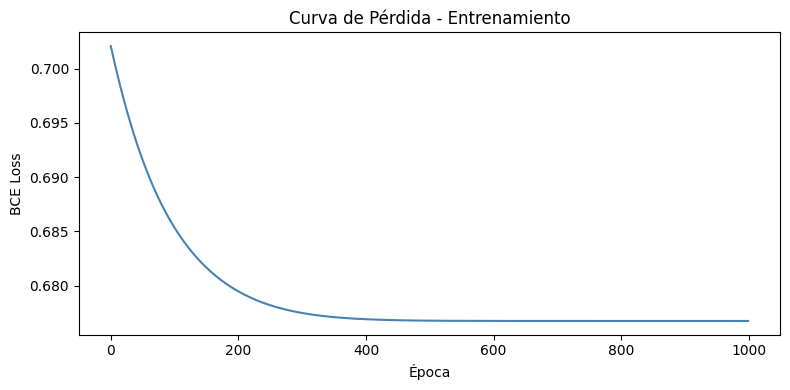

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue')
plt.title('Curva de Pérdida - Entrenamiento')
plt.xlabel('Época')
plt.ylabel('BCE Loss')
plt.tight_layout()
plt.show()


In [ ]:
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_test  = model(X_test_tensor)

train_predicted = (y_pred_train >= 0.5).float()
test_predicted  = (y_pred_test  >= 0.5).float()

train_accuracy = (train_predicted == y_train_tensor).float().mean().item()
test_accuracy  = (test_predicted  == y_test_tensor ).float().mean().item()

print(f'Accuracy Entrenamiento: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)')
print(f'Accuracy Prueba:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')


Accuracy Entrenamiento: 0.5550 (55.50%)
Accuracy Prueba:        0.5150 (51.50%)


In [ ]:
model_l2     = LogisticRegressionModel(input_dim)
criterion    = weighted_bce
optimizer_l2 = optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=0.01)

n_epochs = 1000
loss_history_l2 = []

for epoch in range(n_epochs):
    model_l2.train()
    optimizer_l2.zero_grad()
    outputs = model_l2(X_train_tensor)
    loss    = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer_l2.step()
    loss_history_l2.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1:4d}/{n_epochs}] | Loss (L2): {loss.item():.4f}')

print('\nEntrenamiento con L2 finalizado.')


Epoch [ 100/1000] | Loss (L2): 0.6943
Epoch [ 200/1000] | Loss (L2): 0.6841
Epoch [ 300/1000] | Loss (L2): 0.6794
Epoch [ 400/1000] | Loss (L2): 0.6776
Epoch [ 500/1000] | Loss (L2): 0.6770
Epoch [ 600/1000] | Loss (L2): 0.6768
Epoch [ 700/1000] | Loss (L2): 0.6768
Epoch [ 800/1000] | Loss (L2): 0.6768
Epoch [ 900/1000] | Loss (L2): 0.6768
Epoch [1000/1000] | Loss (L2): 0.6768

Entrenamiento con L2 finalizado.


In [ ]:
model_l2.eval()
with torch.no_grad():
    y_pred_train_l2 = model_l2(X_train_tensor)
    y_pred_test_l2  = model_l2(X_test_tensor)

train_predicted_l2 = (y_pred_train_l2 >= 0.5).float()
test_predicted_l2  = (y_pred_test_l2  >= 0.5).float()

train_accuracy_l2 = (train_predicted_l2 == y_train_tensor).float().mean().item()
test_accuracy_l2  = (test_predicted_l2  == y_test_tensor ).float().mean().item()

print('=== Comparación sin/con L2 ===')
print(f'Sin L2  -> Train: {train_accuracy*100:.2f}%  |  Test: {test_accuracy*100:.2f}%')
print(f'Con L2  -> Train: {train_accuracy_l2*100:.2f}%  |  Test: {test_accuracy_l2*100:.2f}%')


=== Comparación sin/con L2 ===
Sin L2  -> Train: 55.50%  |  Test: 51.50%
Con L2  -> Train: 55.50%  |  Test: 51.50%


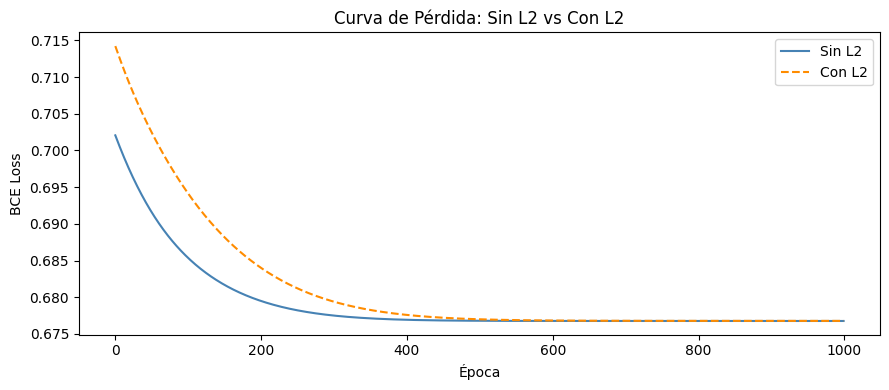

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(loss_history,    label='Sin L2',  color='steelblue')
plt.plot(loss_history_l2, label='Con L2',  color='darkorange', linestyle='--')
plt.title('Curva de Pérdida: Sin L2 vs Con L2')
plt.xlabel('Época')
plt.ylabel('BCE Loss')
plt.legend()
plt.tight_layout()
plt.show()


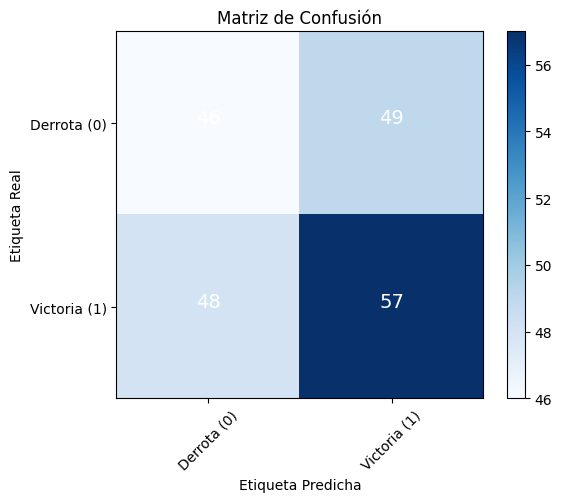

In [ ]:
model_l2.eval()
with torch.no_grad():
    y_pred_test_proba = model_l2(X_test_tensor).numpy().flatten()

y_pred_test_labels = (y_pred_test_proba >= 0.5).astype(int)
y_test_np = y_test_tensor.numpy().flatten().astype(int)

cm = confusion_matrix(y_test_np, y_pred_test_labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['Derrota (0)', 'Victoria (1)'], rotation=45)
plt.yticks(tick_marks, ['Derrota (0)', 'Victoria (1)'])

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black',
             fontsize=14)

plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()


In [ ]:
print('Classification Report:')
print(classification_report(y_test_np, y_pred_test_labels, target_names=['Derrota', 'Victoria']))


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_np, y_pred_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'AUC: {roc_auc:.4f}')


In [ ]:
model_path = 'lol_match_predictor.pth'
torch.save(model_l2.state_dict(), model_path)
print(f'Modelo guardado en: {model_path}')


In [ ]:
model_loaded = LogisticRegressionModel(input_dim)
model_loaded.load_state_dict(torch.load(model_path, weights_only=True))
model_loaded.eval()
print('Modelo cargado correctamente.')


In [ ]:
with torch.no_grad():
    y_pred_loaded = model_loaded(X_test_tensor)

test_predicted_loaded = (y_pred_loaded >= 0.5).float()
test_accuracy_loaded  = (test_predicted_loaded == y_test_tensor).float().mean().item()

print(f'Accuracy del modelo cargado: {test_accuracy_loaded*100:.2f}%')
print(f'Accuracy del modelo original: {test_accuracy_l2*100:.2f}%')
print(f'\nConsistencia: {"OK" if abs(test_accuracy_loaded - test_accuracy_l2) < 1e-6 else "ERROR"}')


In [ ]:
learning_rates = [0.01, 0.05, 0.1]
results = {}

for lr in learning_rates:
    model_tune  = LogisticRegressionModel(input_dim)
    criterion   = nn.BCELoss()
    optimizer   = optim.SGD(model_tune.parameters(), lr=lr)

    model_tune.train()
    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model_tune(X_train_tensor)
        loss    = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    model_tune.eval()
    with torch.no_grad():
        y_pred = model_tune(X_test_tensor)

    predicted = (y_pred >= 0.5).float()
    acc = (predicted == y_test_tensor).float().mean().item()
    results[lr] = acc
    print(f'lr={lr:.3f}  ->  Test Accuracy: {acc*100:.2f}%')

best_lr = max(results, key=results.get)
print(f'\nMejor learning rate: {best_lr} con accuracy de {results[best_lr]*100:.2f}%')


In [ ]:
plt.figure(figsize=(6, 4))
bars = plt.bar([str(lr) for lr in results.keys()],
               [v * 100 for v in results.values()],
               color=['steelblue', 'darkorange', 'seagreen'])
plt.title('Test Accuracy por Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy (%)')
plt.ylim([min(results.values())*100 - 2, max(results.values())*100 + 2])
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
weights  = model_l2.linear.weight.data.numpy().flatten()
features = X.columns

feature_importance = pd.DataFrame({
    'Feature':    features,
    'Importance': weights
})

feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

print('Top 10 características más importantes:')
print(feature_importance[['Feature', 'Importance']].head(10).to_string(index=False))


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['seagreen' if v >= 0 else 'tomato' for v in feature_importance['Importance']]

ax.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color=colors
)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Peso (Importancia)')
ax.set_title('Importancia de Características - Regresión Logística\n(verde = mayor prob. victoria | rojo = mayor prob. derrota)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
print('=' * 50)
print('    RESUMEN DEL PROYECTO')
print('=' * 50)
print(f'Dataset:               {data.shape[0]} partidas, {data.shape[1]-1} features')
print(f'Modelo:                Regresión Logística (PyTorch)')
print(f'Accuracy sin L2:       {test_accuracy*100:.2f}%')
print(f'Accuracy con L2:       {test_accuracy_l2*100:.2f}%')
print(f'AUC-ROC:               {roc_auc:.4f}')
print(f'Mejor learning rate:   {best_lr}')
print(f'Modelo guardado en:    lol_match_predictor.pth')
print('=' * 50)
